# Volatility Modeling & Risk Analysis of NVIDIA (NVDA)

### Big Data & Artificial Intelligence for Operations Management — Project 2, Group 8


# **Introduction & Data Description**

In this project, we analyze the daily closing prices of NVIDIA Corporation (NVDA), one of the fastest-growing technology companies and a global leader in GPU manufacturing. NVDA has been central to major technological shifts such as artificial intelligence, cloud computing, and autonomous vehicles.

The dataset consists of historical daily prices from Yahoo Finance, covering the period 2014–2025. NVIDIA is particularly well-suited for volatility modeling because it exhibits:

* rapid price appreciation,
* strong volatility clustering,
* heavy-tailed return behavior,
* sensitivity to earnings announcements and macroeconomic news.

These characteristics make NVDA an ideal candidate for GARCH-type models and risk estimation techniques such as VaR and ES.

In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm

# DOWNLOAD NVIDIA DAILY PRICES

nvda = yf.download("NVDA", start="2014-01-01", end="2025-01-01", progress=False)

nvda['Log_Return'] = np.log(nvda['Close'] / nvda['Close'].shift(1)) * 100

# Drop first NA and any missing rows
nvda.dropna(inplace=True)

# Also compute absolute log-returns (used later for volatility plots)
nvda['Abs_Log_Return'] = np.abs(nvda['Log_Return'])

nvda.head()

Price,Close,High,Low,Open,Volume,Log_Return,Abs_Log_Return
Ticker,NVDA,NVDA,NVDA,NVDA,NVDA,,
Date,,,,,,,
2014-01-03,0.369385,0.375278,0.368206,0.374571,259332000,-1.205221,1.205221
2014-01-06,0.374335,0.377164,0.369621,0.373157,409492000,1.331257,1.331257
2014-01-07,0.380464,0.381879,0.375514,0.378107,333288000,1.624026,1.624026
2014-01-08,0.385650,0.387536,0.380464,0.381879,308192000,1.353863,1.353863
2014-01-09,0.371271,0.380464,0.370092,0.379757,292172000,-3.799904,3.799904


# **Exploratory Data Analysis**

## 2.1 Price and Log-Return Time Series

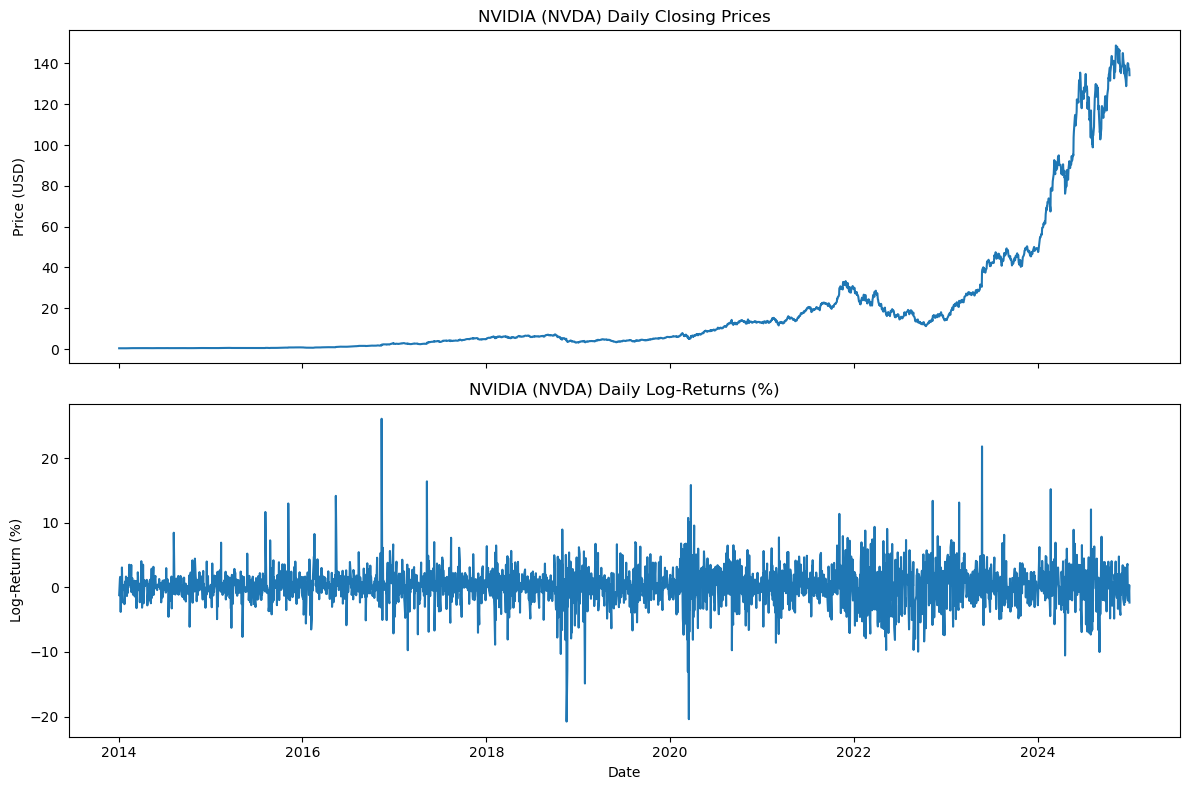

In [2]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Price series
axes[0].plot(nvda.index, nvda['Close'])
axes[0].set_title("NVIDIA (NVDA) Daily Closing Prices")
axes[0].set_ylabel("Price (USD)")

# Log-return series (in %)
axes[1].plot(nvda.index, nvda['Log_Return'])
axes[1].set_title("NVIDIA (NVDA) Daily Log-Returns (%)")
axes[1].set_ylabel("Log-Return (%)")
axes[1].set_xlabel("Date")

plt.tight_layout()
plt.show()

The price plot shows that NVIDIA’s stock has increased sharply over time, especially in the 
most recent years, indicating strong growth but also periods of rapid movement. The log-return 
plot shows frequent spikes, meaning there are days with unusually large gains or losses. 
Overall, the returns do not appear stable over time, suggesting that volatility changes from 
period to period. This motivates the use of time-varying volatility models such as GARCH.

## 2.2 Summary Statistics

Summary Statistics for NVDA Log-Returns (%)
Mean:               0.2126
Variance:           8.6114
Skewness:           0.2253
Kurtosis:           10.2854
Normality Test p-value: 0.0000  -->  Not Normal


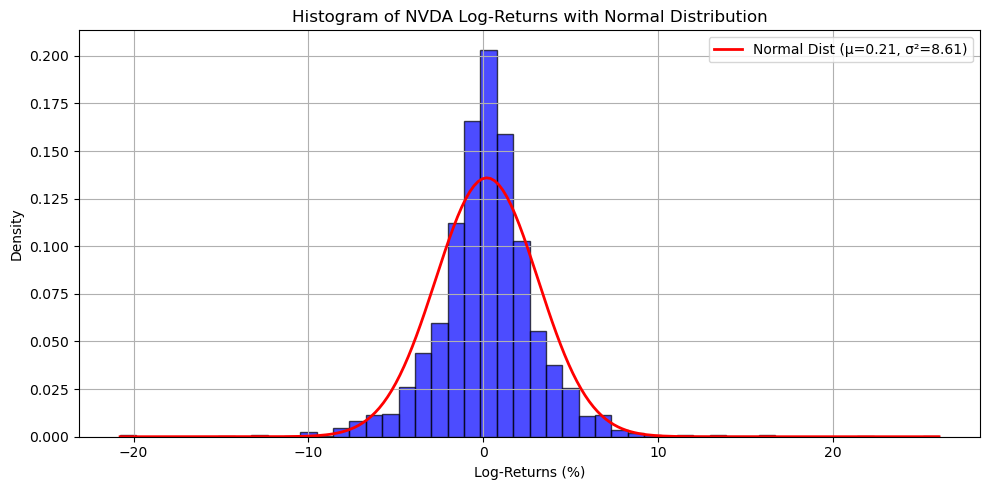

In [3]:
from scipy.stats import skew, kurtosis, normaltest, norm
import numpy as np
import matplotlib.pyplot as plt

returns = nvda['Log_Return']

mean_return = np.mean(returns)
variance_return = np.var(returns)
skewness_return = skew(returns)
kurtosis_return = kurtosis(returns, fisher=False)

stats_test, p_value = normaltest(returns)
normality_result = "Normal" if p_value > 0.05 else "Not Normal"

print("Summary Statistics for NVDA Log-Returns (%)")

print(f"Mean:               {mean_return:.4f}")
print(f"Variance:           {variance_return:.4f}")
print(f"Skewness:           {skewness_return:.4f}")
print(f"Kurtosis:           {kurtosis_return:.4f}")  
print(f"Normality Test p-value: {p_value:.4f}  -->  {normality_result}")


plt.figure(figsize=(10, 5))


count, bins, _ = plt.hist(returns,bins=50,alpha=0.7,color='blue',edgecolor='black',density=True)

x = np.linspace(bins[0], bins[-1], 200)
pdf = norm.pdf(x, mean_return, np.sqrt(variance_return))

plt.plot(x, pdf, color='red', lw=2,label=f'Normal Dist (μ={mean_return:.2f}, σ²={variance_return:.2f})')

plt.xlabel("Log-Returns (%)")
plt.ylabel("Density")
plt.title("Histogram of NVDA Log-Returns with Normal Distribution")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### Interpretation of Summary Statistics and Distribution of Returns
The mean daily log-return of NVIDIA is close to zero, which is typical for a financial asset. 
The standard deviation shows that NVDA experiences noticeable day-to-day volatility.

The skewness is close to zero, indicating that the distribution of returns is roughly symmetric. 
However, the kurtosis is well above 3, meaning that NVDA has fat tails and experiences more extreme 
returns than a normal distribution would predict.

The histogram and fitted normal curve confirm this: the empirical distribution is more peaked in 
the center and has heavier tails. The normality test also rejects the assumption of normality.

Overall, the return distribution is non-normal and heavy-tailed, which is consistent with financial 
market behavior and supports the use of volatility models such as GARCH.


## 2.3 Volatility Clustering

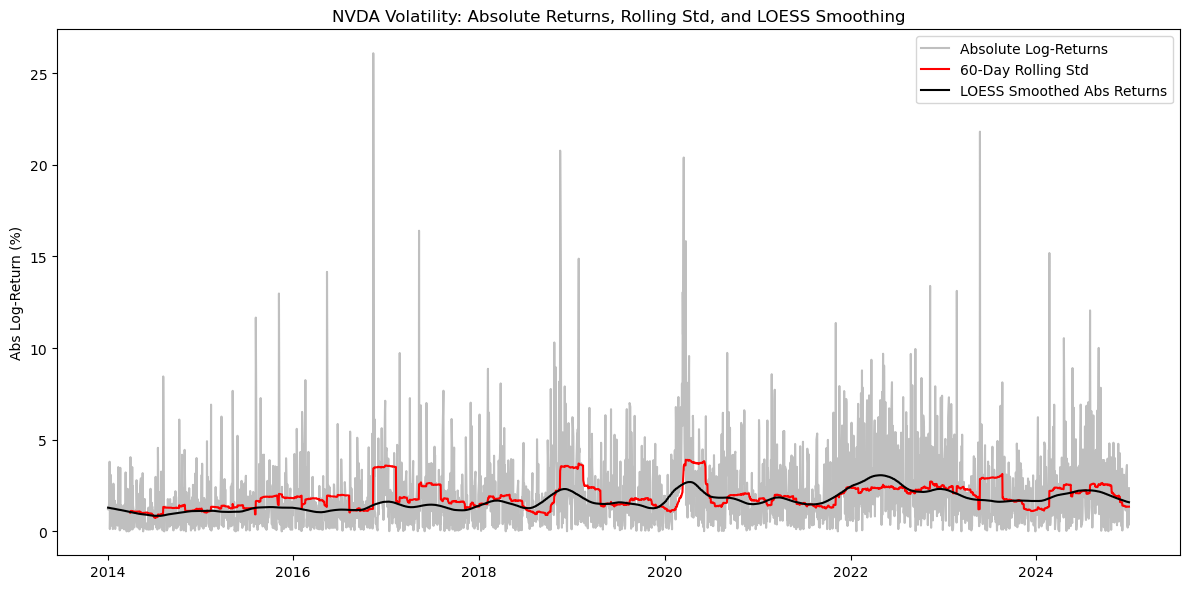

In [4]:
window_size = 60 

nvda['Rolling_Std'] = nvda['Abs_Log_Return'].rolling(window=window_size).std()

# LOESS smoothing of absolute returns)
lowess = sm.nonparametric.lowess
smoothed_abs = lowess(nvda['Abs_Log_Return'],np.arange(len(nvda['Abs_Log_Return'])),frac=0.05)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(nvda.index, nvda['Abs_Log_Return'], color='gray', alpha=0.5, label='Absolute Log-Returns')
ax.plot(nvda.index, nvda['Rolling_Std'], color='red', label=f'{window_size}-Day Rolling Std')
ax.plot(nvda.index, smoothed_abs[:, 1], color='black', label='LOESS Smoothed Abs Returns')

ax.set_title("NVDA Volatility: Absolute Returns, Rolling Std, and LOESS Smoothing")
ax.set_ylabel("Abs Log-Return (%)")
ax.legend()

plt.tight_layout()
plt.show()

The absolute returns and rolling standard deviation show clear volatility clustering.
Large absolute returns tend to be followed by more large absolute returns, and calm periods follow calm periods.
This is consistent with financial time series behavior and motivates ARCH/GARCH modeling.

## 2.4 ACF and PACF of Returns and Squared Returns

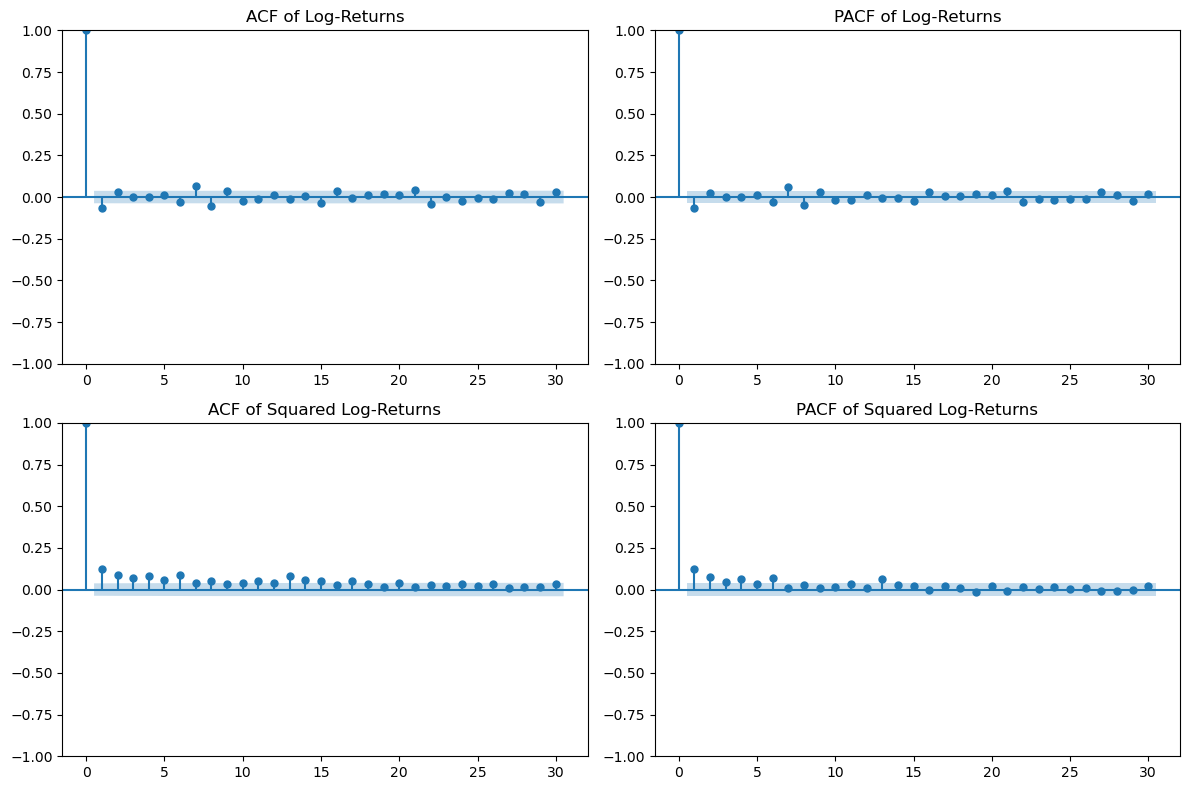

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# ACF and PACF of log-returns
plot_acf(returns, lags=30, ax=axes[0, 0])
axes[0, 0].set_title("ACF of Log-Returns")

plot_pacf(returns, lags=30, ax=axes[0, 1], method='ywm')
axes[0, 1].set_title("PACF of Log-Returns")

# ACF and PACF of squared log-returns
squared_returns = returns**2

plot_acf(squared_returns, lags=30, ax=axes[1, 0])
axes[1, 0].set_title("ACF of Squared Log-Returns")

plot_pacf(squared_returns, lags=30, ax=axes[1, 1], method='ywm')
axes[1, 1].set_title("PACF of Squared Log-Returns")

plt.tight_layout()
plt.show()

The ACF and PACF of squared returns show significant autocorrelation at several lags, indicating volatility clustering and dependence in the conditional variance.

This behavior is characteristic of heteroskedastic financial series and supports the use of ARCH/GARCH models.

## 2.5 Stationary Tests (ADF)

In [6]:
from statsmodels.tsa.stattools import adfuller

# ADF test on price
adf_price = adfuller(nvda['Close'])
print("ADF test on price")
print(f"Test statistic: {adf_price[0]:.4f}")
print(f"p-value: {adf_price[1]:.4f}")
print("Critical values:")
for key, value in adf_price[4].items():
    print(f"   {key}: {value:.4f}")

print("\n" + "-"*40 + "\n")

# ADF test on log-returns
adf_ret = adfuller(returns)
print("ADF test on log-returns")
print(f"Test statistic: {adf_ret[0]:.4f}")
print(f"p-value: {adf_ret[1]:.4f}")
print("Critical values:")
for key, value in adf_ret[4].items():
    print(f"   {key}: {value:.4f}")

ADF test on price
Test statistic: 2.9899
p-value: 1.0000
Critical values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673

----------------------------------------

ADF test on log-returns
Test statistic: -17.0928
p-value: 0.0000
Critical values:
   1%: -3.4327
   5%: -2.8626
   10%: -2.5673


### Interpretation Price Series
We fail to reject the null hypothesis of a unit root; the NVDA price series is non-stationary

### Interpretation Log-Return Series
We reject the null hypothesis of a unit root; the log-return series is stationary, consistent with financial theory and appropriate for GARCH modeling.


# **Volatility Modeling**

## 3.1 Testing an ARCH(1) Model


ARCH(1) Model Summary:
                           AR - ARCH Model Results                            
Dep. Variable:             Log_Return   R-squared:                       0.004
Mean Model:                        AR   Adj. R-squared:                  0.004
Vol Model:                       ARCH   Log-Likelihood:               -6833.52
Distribution:                  Normal   AIC:                           13675.0
Method:            Maximum Likelihood   BIC:                           13698.7
                                        No. Observations:                 2766
Date:                Wed, Dec 17 2025   Df Residuals:                     2764
Time:                        23:41:45   Df Model:                            2
                                  Mean Model                                  
                    coef    std err          t      P>|t|     95.0% Conf. Int.
------------------------------------------------------------------------------
Const             0.2686  6.

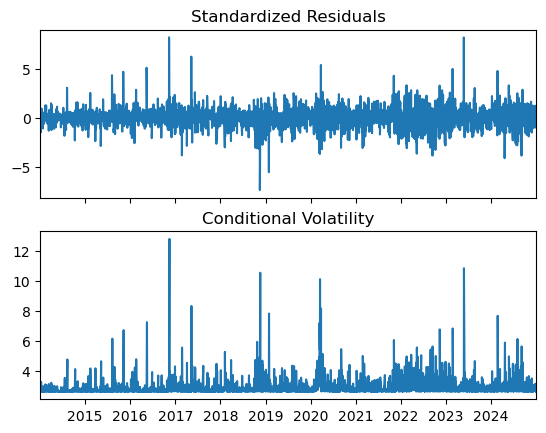

In [7]:
from arch import arch_model

# ARCH(1) with AR(1) mean, normal errors (simple baseline model)
arch1_model = arch_model(returns,mean='AR',lags=1,vol='ARCH',p=1,dist='normal')

arch1_fit = arch1_model.fit(disp='off')

print("\nARCH(1) Model Summary:")
print(arch1_fit.summary())

fig = arch1_fit.plot()
plt.show()

The ARCH(1) model serves as a baseline but is expected to be outperformed by the GARCH model due to NVIDIA’s persistent volatility.

## 3.2 Fitting a GARCH(1,1) Model


Model Summary:
                              AR - GARCH Model Results                              
Dep. Variable:                   Log_Return   R-squared:                       0.003
Mean Model:                              AR   Adj. R-squared:                  0.003
Vol Model:                            GARCH   Log-Likelihood:               -6502.24
Distribution:      Standardized Student's t   AIC:                           13016.5
Method:                  Maximum Likelihood   BIC:                           13052.0
                                              No. Observations:                 2766
Date:                      Wed, Dec 17 2025   Df Residuals:                     2764
Time:                              23:41:45   Df Model:                            2
                                   Mean Model                                   
                    coef    std err          t      P>|t|       95.0% Conf. Int.
---------------------------------------------------------

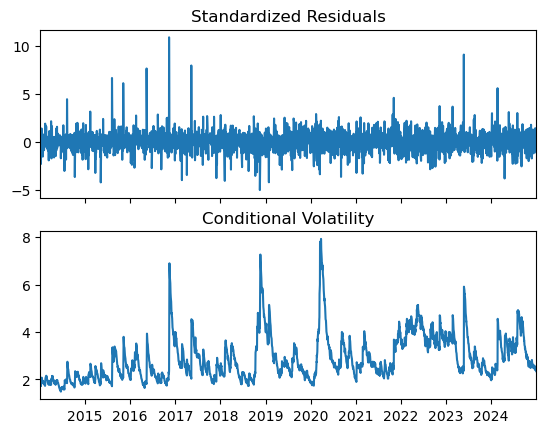

In [8]:
from arch import arch_model

# Use your NVDA returns
returns = nvda['Log_Return'].dropna()

# Fit GARCH(1,1) with t-distributed errors
garch_model = arch_model(returns,mean='AR',lags=1,vol='Garch',p=1,o=0,q=1,dist='t')

garch_fit = garch_model.fit(disp='off')

print("\nModel Summary:")
print(garch_fit.summary())

fig = garch_fit.plot()
plt.show()

### Interpretation of GARCH(1,1) Model

The GARCH(1,1) model does a very good job at capturing the volatility pattern in NVIDIA’s 
log-returns. The ARCH term (α₁) is significant, meaning that large movements in returns 
increase volatility on the following days. The GARCH term (β₁) is also highly significant 
and quite large. This indicates that once volatility becomes high, it tends to stay high 
for a while. This matches what we saw earlier: NVIDIA has clear volatility clustering.

The sum α₁ + β₁ is close to 1, which means volatility is very persistent — again consistent 
with the visual patterns in the data. The model also uses a t-distribution for the errors, 
and the estimated degrees of freedom are low, which confirms that NVIDIA returns have 
heavy tails (more extreme movements than a normal distribution would predict).

Overall, the GARCH(1,1) model clearly improves on the simpler ARCH(1) model and captures 
NVIDIA’s volatility much more effectively. This makes it a good choice for the risk 
estimation (VaR and ES) carried out in the next section.


## 3.3 Visualizing Volatility

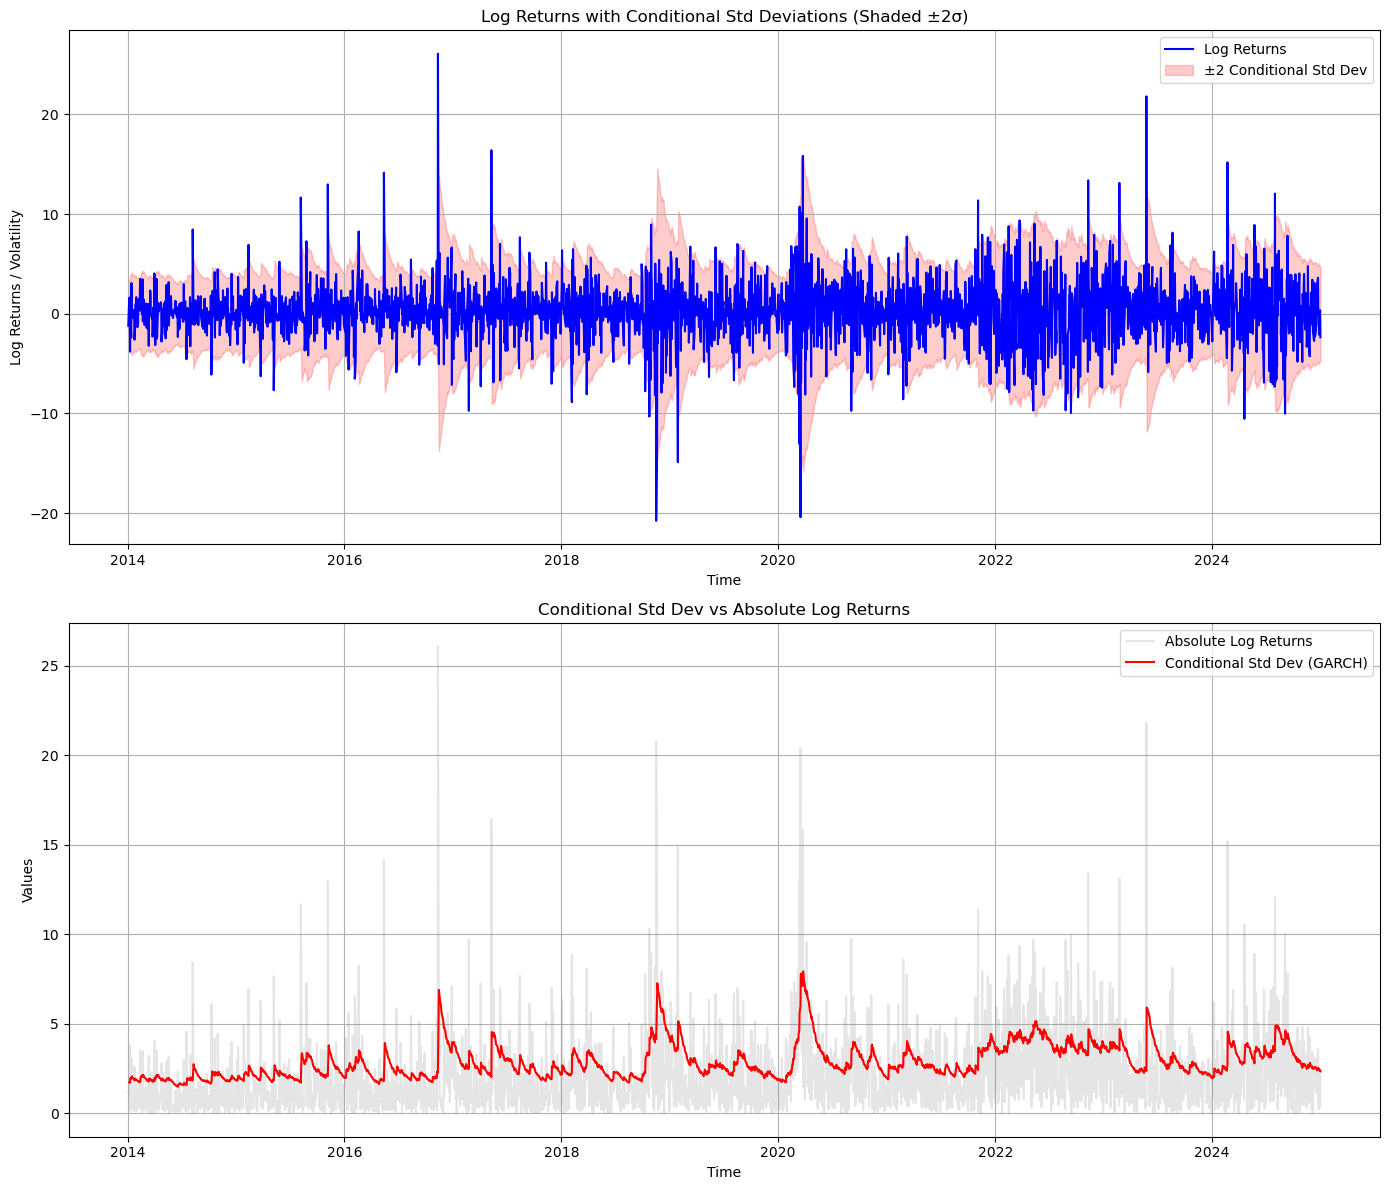

In [9]:
import numpy as np
import matplotlib.pyplot as plt

# Extract conditional volatility (sigma_t)
conditional_volatility = garch_fit.conditional_volatility
abs_log_returns = np.abs(returns)

# Combined plot with two subplots stacked vertically
fig, axs = plt.subplots(2, 1, figsize=(14, 12))

# Plot 1: Log returns with shaded ±2 conditional std dev bands
axs[0].plot(returns.index, returns, label='Log Returns', color='blue')

upper_bound = 2 * conditional_volatility
lower_bound = -2 * conditional_volatility

axs[0].fill_between(returns.index,lower_bound,upper_bound,color='red',alpha=0.2,label='±2 Conditional Std Dev')

axs[0].set_title('Log Returns with Conditional Std Deviations (Shaded ±2σ)')
axs[0].set_ylabel('Log Returns / Volatility')
axs[0].set_xlabel('Time')
axs[0].legend()
axs[0].grid(True)

# Plot 2: Conditional Std Dev vs. Absolute Log Returns
axs[1].plot(abs_log_returns.index,abs_log_returns,label='Absolute Log Returns',color='gray',alpha=0.2)

axs[1].plot(conditional_volatility.index,conditional_volatility,label='Conditional Std Dev (GARCH)',color='red')

axs[1].set_title('Conditional Std Dev vs Absolute Log Returns')
axs[1].set_ylabel('Values')
axs[1].set_xlabel('Time')
axs[1].legend()
axs[1].grid(True)

# Adjust layout and display
plt.tight_layout()
plt.show()

The shaded ±2σ bands in the first plot show that NVIDIA’s volatility is not constant. 
During more turbulent periods, the bands widen, and during calmer periods they narrow. 
This matches the volatility clustering we observed earlier.

In the second plot, the conditional standard deviation from the GARCH model moves closely 
with the absolute log-returns. When the absolute returns spike, the model’s estimated 
volatility also increases. This shows that the GARCH model is capturing the changes in 
volatility over time.

## 3.4 ARCH and GARCH Comparison

In [10]:
print("Model Comparison:")
print(f"ARCH(1)  AIC: {arch1_fit.aic:.2f}, BIC: {arch1_fit.bic:.2f}")
print(f"GARCH(1,1) AIC: {garch_fit.aic:.2f}, BIC: {garch_fit.bic:.2f}")

Model Comparison:
ARCH(1)  AIC: 13675.03, BIC: 13698.73
GARCH(1,1) AIC: 13016.48, BIC: 13052.03


Based on AIC and BIC values, the GARCH(1,1) model clearly outperforms the ARCH(1) model. The lower AIC and BIC 
indicate that GARCH(1,1) captures the volatility structure more efficiently, likely due to its ability to account for 
both short-term shocks (α₁) and longer-term volatility persistence (β₁). Therefore, GARCH(1,1) is selected as the 
preferred volatility model for NVIDIA.

## 3.5 Residual Analysis and Autocorelation (ACF of Residuals & Squared Residuals)

Ljung-Box test on standardized residuals (lag 10):
     lb_stat  lb_pvalue
10  8.291824   0.600355 

Ljung-Box test on squared standardized residuals (lag 10):
     lb_stat  lb_pvalue
10  2.844212   0.984856


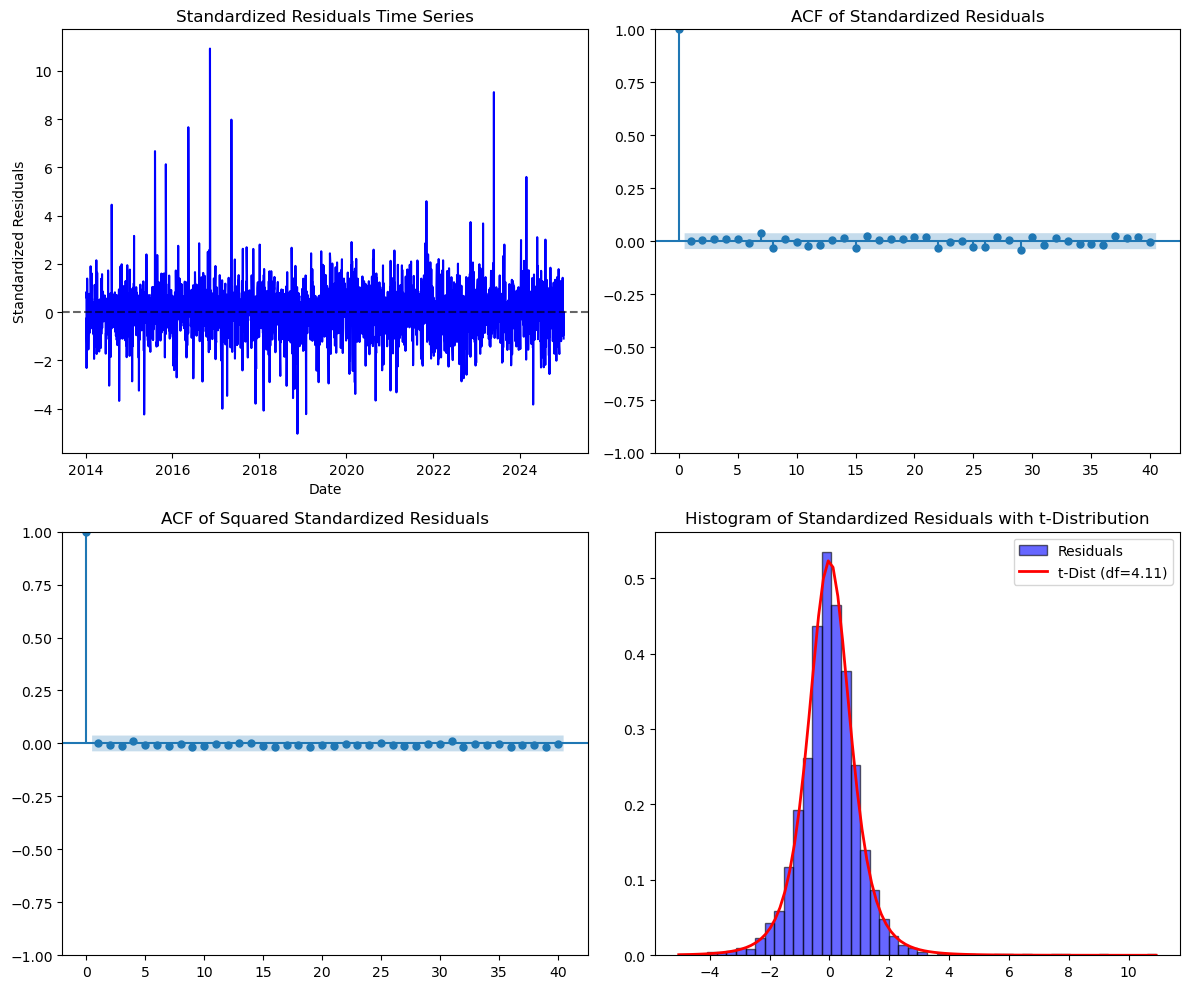

In [11]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox   # <-- needed import
from scipy.stats import t, probplot

# Compute standardized residuals
std_residuals = garch_fit.resid / garch_fit.conditional_volatility
std_residuals = std_residuals.dropna()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Standardized residual time series
sns.lineplot(x=std_residuals.index, y=std_residuals, ax=axes[0, 0], color='blue')
axes[0, 0].set_title("Standardized Residuals Time Series")
axes[0, 0].set_ylabel("Standardized Residuals")
axes[0, 0].axhline(y=0, color='black', linestyle='--', alpha=0.6)

# 2. ACF of standardized residuals
plot_acf(std_residuals, ax=axes[0, 1], lags=40)
axes[0, 1].set_title("ACF of Standardized Residuals")

# 3. ACF of squared standardized residuals
plot_acf(std_residuals**2, ax=axes[1, 0], lags=40)
axes[1, 0].set_title("ACF of Squared Standardized Residuals")

# 4. Histogram + fitted t-distribution for standardized residuals
df_t, loc_t, scale_t = t.fit(std_residuals)
x = np.linspace(min(std_residuals), max(std_residuals), 100)
pdf_t = t.pdf(x, df_t, loc=loc_t, scale=scale_t)

axes[1, 1].hist(std_residuals, bins=50, density=True,
                alpha=0.6, color='blue', edgecolor='black', label="Residuals")
axes[1, 1].plot(x, pdf_t, color='red', lw=2,
                label=f't-Dist (df={df_t:.2f})')
axes[1, 1].set_title("Histogram of Standardized Residuals with t-Distribution")
axes[1, 1].legend()

# Ljung-Box tests at lag 10
lb_resid = acorr_ljungbox(std_residuals, lags=[10], return_df=True)
lb_sq    = acorr_ljungbox(std_residuals**2, lags=[10], return_df=True)

print("Ljung-Box test on standardized residuals (lag 10):")
print(lb_resid, "\n")
print("Ljung-Box test on squared standardized residuals (lag 10):")
print(lb_sq)

plt.tight_layout()
plt.show()

The standardized residuals fluctuate randomly around zero and show no visible patterns. 

The ACF of the residuals shows no significant autocorrelation, indicating that the AR(1) + GARCH(1,1)–t model adequately captures the linear dependence structure. The squared residuals also show no significant remaining autocorrelation, suggesting that the model has effectively removed conditional heteroskedasticity. 

The histogram and t-distribution overlay confirm that the heavy tails of the standardized residuals are consistent with the fitted t-distribution.

# Risk Modeling

## 4.1 Compute VaR at different confidence levels

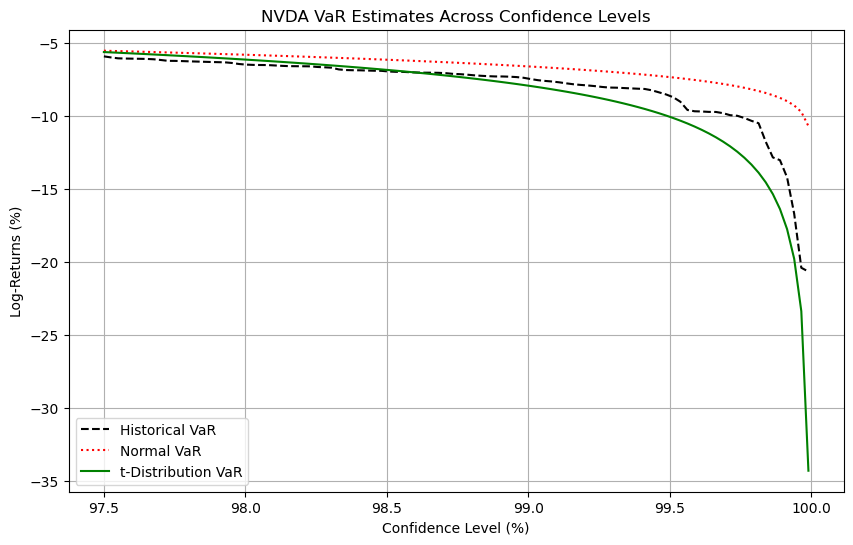

In [12]:
from scipy.stats import norm, t
import numpy as np
import matplotlib.pyplot as plt

returns = nvda['Log_Return'].dropna()

confidence_levels = np.linspace(0.975, 0.9999, 100)

VaR_hist = [np.percentile(returns, (1 - alpha) * 100) for alpha in confidence_levels]

mean_ret = returns.mean()
std_ret = returns.std()
VaR_norm = [norm.ppf(1 - alpha, loc=mean_ret, scale=std_ret) for alpha in confidence_levels]

df, loc_t, scale_t = t.fit(returns)
VaR_t = [loc_t + scale_t * t.ppf(1 - alpha, df) for alpha in confidence_levels]

plt.figure(figsize=(10, 6))
plt.plot(confidence_levels * 100, VaR_hist, label='Historical VaR', linestyle='dashed', color='black')
plt.plot(confidence_levels * 100, VaR_norm, label='Normal VaR', linestyle='dotted', color='red')
plt.plot(confidence_levels * 100, VaR_t, label='t-Distribution VaR', linestyle='solid', color='green')

plt.xlabel("Confidence Level (%)")
plt.ylabel("Log-Returns (%)")
plt.title("NVDA VaR Estimates Across Confidence Levels")
plt.grid(True)
plt.legend()
plt.show()

The VaR curves show how much NVIDIA could lose on a bad day at different confidence levels. 
As the confidence level increases, all VaR estimates become more negative, meaning larger 
potential losses.

The t-distribution VaR is the most conservative (most negative), followed by the historical VaR, 
and then the Normal VaR. This makes sense because NVIDIA’s returns have heavy tails, so the 
t-distribution captures extreme losses better than the normal assumption.

## 4.2 Compute Expected Shortfall (ES)

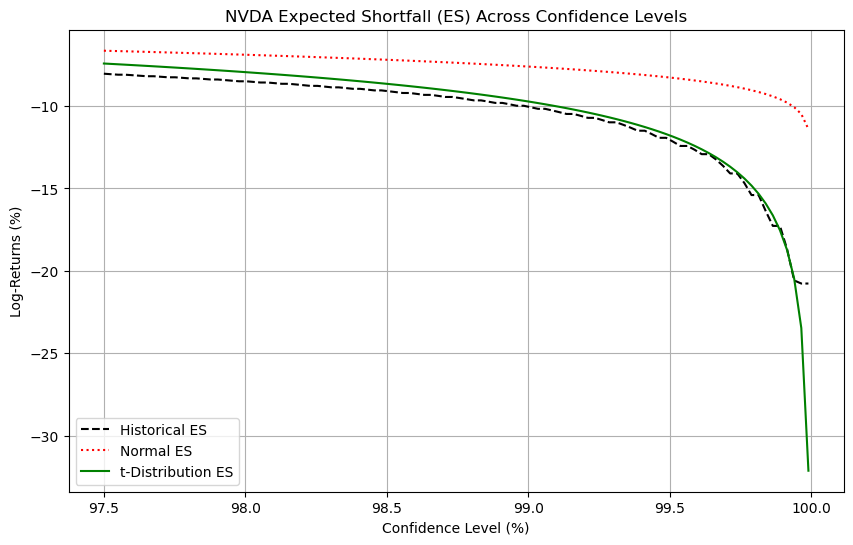

In [13]:
# Normal ES
z_alpha = norm.ppf(confidence_levels)
phi_norm = norm.pdf(z_alpha)
ES_norm = mean_ret - std_ret * (phi_norm / (1 - confidence_levels))

# t ES
t_alpha = t.ppf(confidence_levels, df_t)
t_pdf_alpha = t.pdf(t_alpha, df_t)
ES_t = loc_t - scale_t * (t_pdf_alpha / (1 - confidence_levels)) * (df_t + t_alpha**2) / (df_t - 1)

# Historical ES
ES_hist = [returns[returns <= VaR_hist[i]].mean() for i in range(len(confidence_levels))]

plt.figure(figsize=(10, 6))
plt.plot(confidence_levels * 100, ES_hist, label='Historical ES', linestyle='dashed', color='black')
plt.plot(confidence_levels * 100, ES_norm, label='Normal ES', linestyle='dotted', color='red')
plt.plot(confidence_levels * 100, ES_t, label='t-Distribution ES', linestyle='solid', color='green')

plt.xlabel("Confidence Level (%)")
plt.ylabel("Log-Returns (%)")
plt.title("NVDA Expected Shortfall (ES) Across Confidence Levels")
plt.legend()
plt.grid(True)
plt.show()

Expected Shortfall (ES) gives the average loss on the days when VaR is exceeded. 
As expected, ES values are always more negative than the corresponding VaR values, since 
they represent even more extreme outcomes.

Again, the t-distribution produces the largest (most negative) ES, indicating that the 
heavier-tailed model expects bigger losses during extreme market events. This highlights 
that NVIDIA carries substantial tail risk.


## 4.3 Dynamic Risk Modelling

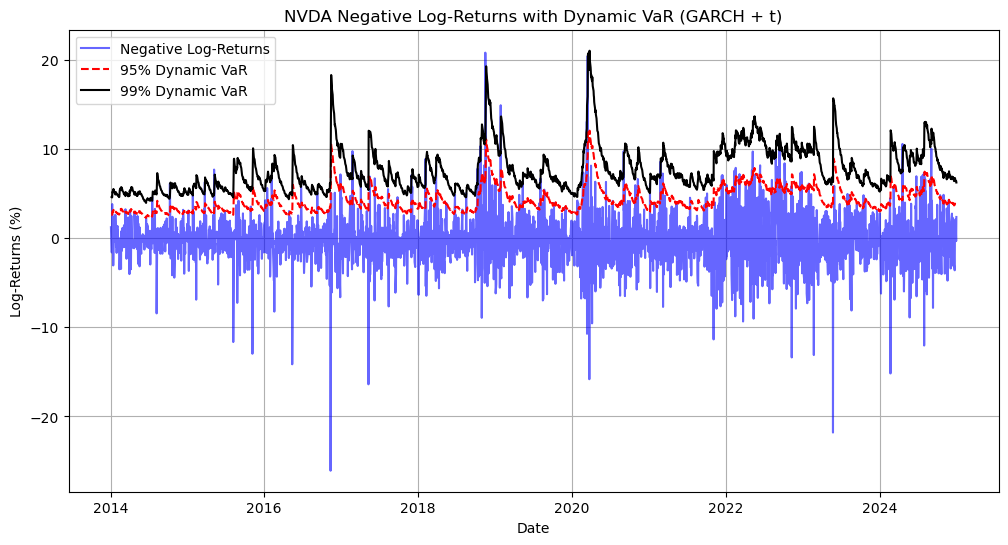

In [14]:
# Dynamic Risk Modeling

# Standardized residuals and conditional volatility
std_residuals = garch_fit.resid / garch_fit.conditional_volatility
std_residuals = std_residuals.dropna()
cond_volatility = garch_fit.conditional_volatility.dropna()

# Fit t to standardized residuals
df_t_res, loc_t_res, scale_t_res = t.fit(std_residuals)

# Dynamic VaR series (95%, 99%)
VaR_95 = -scale_t_res * t.ppf(0.05, df_t_res) * cond_volatility
VaR_99 = -scale_t_res * t.ppf(0.01, df_t_res) * cond_volatility

plt.figure(figsize=(12, 6))
plt.plot(-returns, label="Negative Log-Returns", color='blue', alpha=0.6)
plt.plot(VaR_95, label="95% Dynamic VaR", linestyle='dashed', color='red')
plt.plot(VaR_99, label="99% Dynamic VaR", linestyle='solid', color='black')

plt.xlabel("Date")
plt.ylabel("Log-Returns (%)")
plt.title("NVDA Negative Log-Returns with Dynamic VaR (GARCH + t)")
plt.legend()
plt.grid(True)
plt.show()

The dynamic VaR plot shows how risk changes over time. During periods where NVIDIA’s returns 
are more volatile, the VaR lines move upward, indicating higher expected losses. During calmer 
periods, the VaR levels drop.

The fact that the 95% and 99% Dynamic VaR adjust with the volatility of the market means the 
GARCH model is capturing changing risk conditions well. This confirms that NVIDIA’s risk is 
not constant over time and increases noticeably during more turbulent periods.

## 4.4 Forecasting

In [15]:
# ---------------- GARCH One-Step-Ahead Forecasting ---------------- #

# Use the fitted GARCH(1,1)–t model
forecast = garch_fit.forecast(horizon=1)

# Forecasted next-day conditional variance
next_var = forecast.variance.iloc[-1, 0]

# Convert to volatility
next_vol = np.sqrt(next_var)

# Forecasted mean return (AR(1) part)
next_mean = forecast.mean.iloc[-1, 0]

print("Next-Day Forecasts from GARCH(1,1)-t Model")
print("------------------------------------------")
print(f"Forecasted Mean Return:      {next_mean:.6f}")
print(f"Forecasted Volatility (σ):   {next_vol:.6f}")
print(f"Forecasted Variance (σ²):    {next_var:.6f}")


Next-Day Forecasts from GARCH(1,1)-t Model
------------------------------------------
Forecasted Mean Return:      0.294305
Forecasted Volatility (σ):   2.376860
Forecasted Variance (σ²):    5.649465


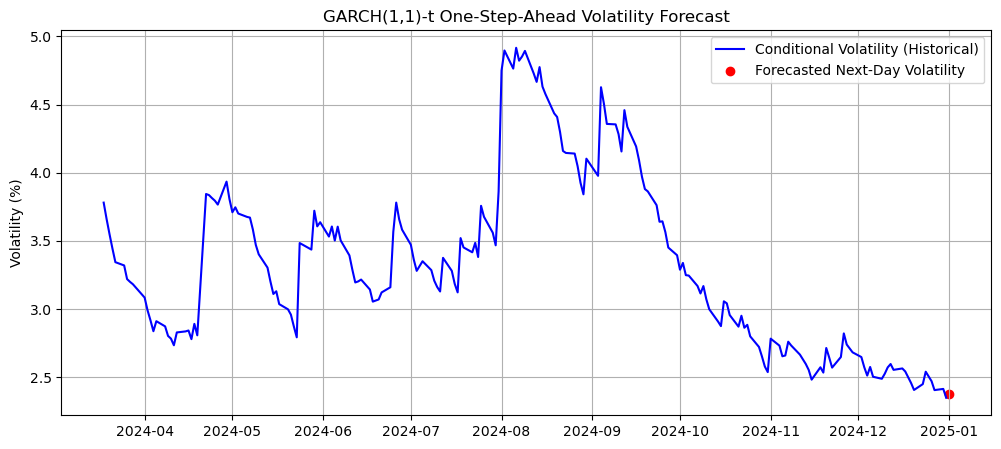

In [16]:
# ---------------- Plotting the Volatility Forecast ---------------- #

plt.figure(figsize=(12,5))

# Last 200 days of volatility
plt.plot(garch_fit.conditional_volatility[-200:], label="Conditional Volatility (Historical)", color="blue")

# Add the forecast point
plt.scatter(garch_fit.conditional_volatility.index[-1] + pd.Timedelta(days=1),
            next_vol,
            color='red',
            label="Forecasted Next-Day Volatility")

plt.title("GARCH(1,1)-t One-Step-Ahead Volatility Forecast")
plt.ylabel("Volatility (%)")
plt.legend()
plt.grid(True)
plt.show()

### Forecasting with the GARCH(1,1)-t Model

The fitted GARCH model provides one-step-ahead forecasts for both the expected return and 
the conditional volatility of NVIDIA. These forecasts represent the model’s prediction for 
tomorrow’s market conditions based on today’s information.

The predicted volatility is particularly important because it directly feeds into risk measures 
such as VaR and ES. A higher forecasted volatility implies higher anticipated risk. The 
one-step-ahead forecast point plotted at the end of the volatility series shows how the model 
extends the volatility dynamics into the future.

These forecasts can support financial decision-making by helping investors and risk managers 
anticipate short-term uncertainty and adjust risk exposures accordingly.

## Conclusions - Financial Implications

The VaR and ES results provide important insight into NVIDIA’s downside risk exposure. 
At higher confidence levels, both measures indicate that NVDA can experience large and sudden losses, 
reflecting the company’s sensitivity to market volatility and sector-specific shocks in the 
technology and semiconductor industries.

From a financial perspective, the 95% and 99% VaR values quantify the maximum expected loss on a typical 
trading day under normal conditions, while the ES values provide the expected loss when conditions are worse 
than the VaR threshold. Since ES is consistently more negative than VaR, this indicates that actual losses 
during extreme events can be substantially larger than what VaR alone suggests.

These findings imply that investors, portfolio managers, and operations planners need to account for the 
possibility of extreme downside movements when holding NVDA. Higher capital reserves, hedging strategies, 
or risk limits may be necessary to manage exposure. The results also highlight the importance of monitoring 
market conditions closely: during periods of elevated volatility, the potential financial impact of holding 
NVDA increases significantly. Overall, the risk estimates suggest that NVDA is a high-volatility asset that 
requires robust risk management practices.
